In [16]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("All libraries imported successfully!")

All libraries imported successfully!


In [19]:
df = pd.read_csv('Housing.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [20]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [21]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [22]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


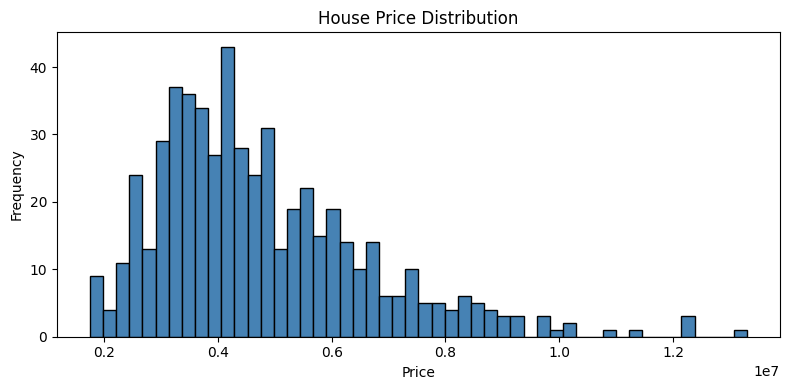

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(df['price'], bins=50, color='steelblue', edgecolor='black')
plt.title('House Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

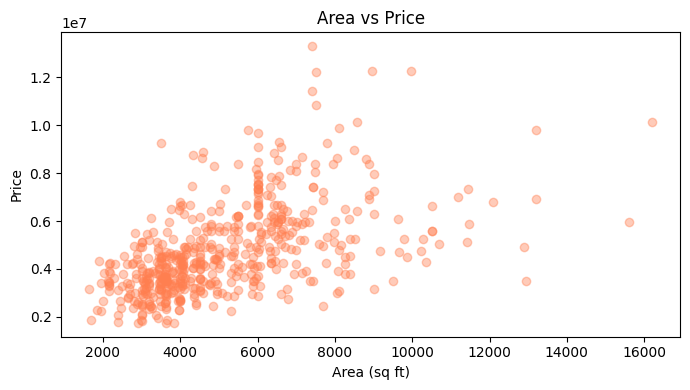

In [24]:
plt.figure(figsize=(7, 4))
plt.scatter(df['area'], df['price'], alpha=0.4, color='coral')
plt.title('Area vs Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [25]:
# These columns have yes/no or category values — we convert them to numbers
le = LabelEncoder()

categorical_cols = ['mainroad', 'guestroom', 'basement', 
                    'hotwaterheating', 'airconditioning', 
                    'prefarea', 'furnishingstatus']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding complete!")
df.head()

Encoding complete!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


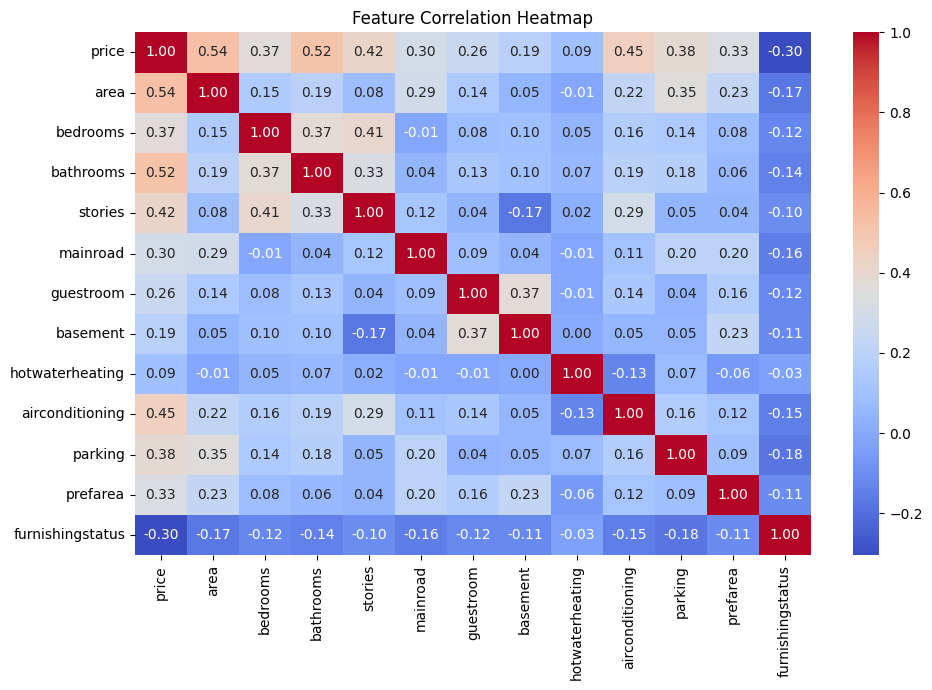

In [26]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [27]:
# Features and target
X = df.drop('price', axis=1)
y = df['price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print("Preprocessing complete!")

Training samples : 436
Testing samples  : 109
Preprocessing complete!


In [28]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

print("=== Linear Regression Results ===")
print(f"MAE  : {lr_mae:,.2f}")
print(f"RMSE : {lr_rmse:,.2f}")

=== Linear Regression Results ===
MAE  : 979,679.69
RMSE : 1,331,071.42


In [29]:
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

gb_predictions = gb_model.predict(X_test_scaled)

gb_mae  = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))

print("=== Gradient Boosting Results ===")
print(f"MAE  : {gb_mae:,.2f}")
print(f"RMSE : {gb_rmse:,.2f}")

=== Gradient Boosting Results ===
MAE  : 964,058.87
RMSE : 1,301,871.87


               Model        MAE        RMSE
0  Linear Regression  979679.69  1331071.42
1  Gradient Boosting  964058.87  1301871.87


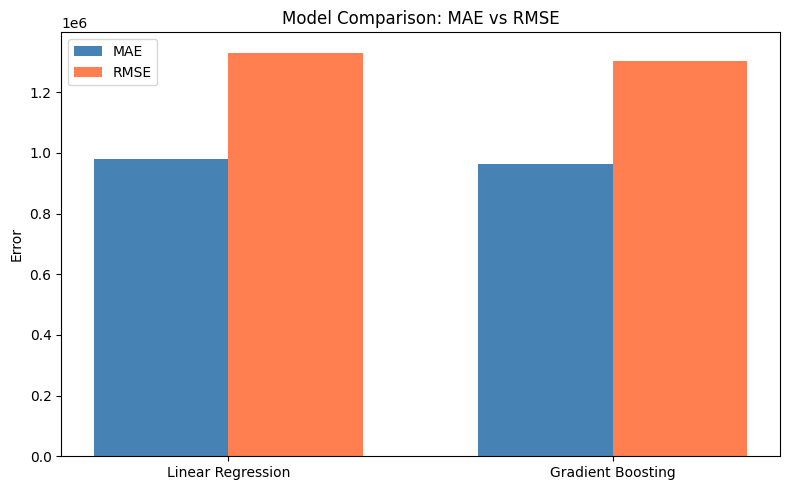

In [30]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Gradient Boosting'],
    'MAE': [round(lr_mae, 2), round(gb_mae, 2)],
    'RMSE': [round(lr_rmse, 2), round(gb_rmse, 2)]
})

print(results)

# Bar chart
x = np.arange(2)
width = 0.35
models = ['Linear Regression', 'Gradient Boosting']

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, [lr_mae, gb_mae], width, label='MAE', color='steelblue')
ax.bar(x + width/2, [lr_rmse, gb_rmse], width, label='RMSE', color='coral')
ax.set_title('Model Comparison: MAE vs RMSE')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Error')
ax.legend()
plt.tight_layout()
plt.show()

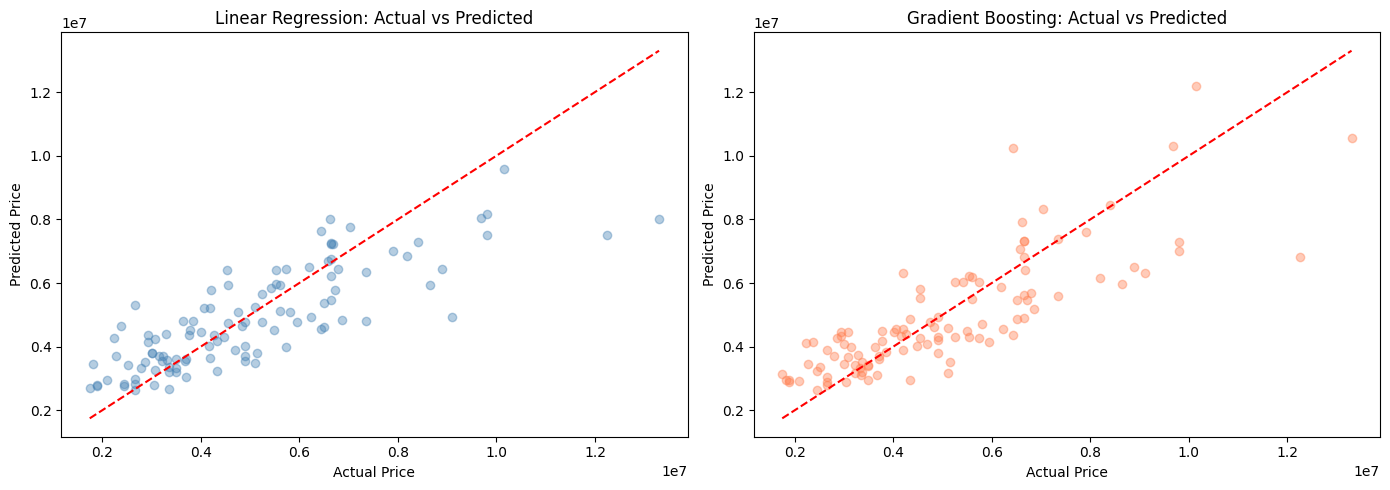

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(y_test, lr_predictions, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

# Gradient Boosting
axes[1].scatter(y_test, gb_predictions, alpha=0.4, color='coral')
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('Gradient Boosting: Actual vs Predicted')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

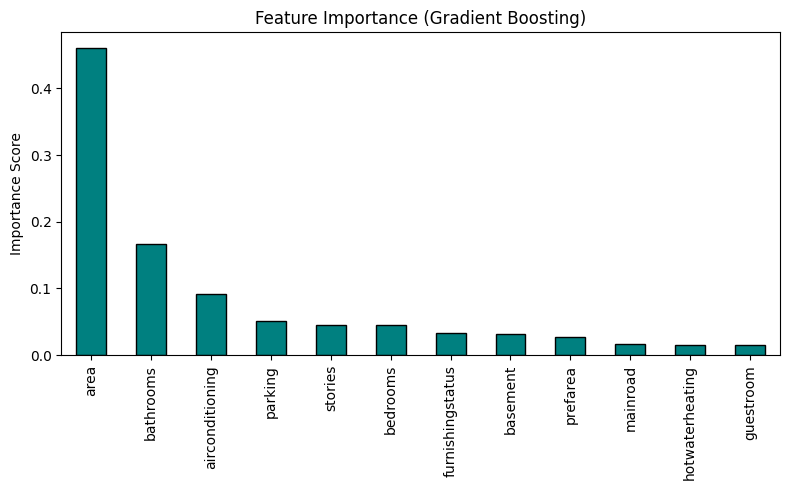

In [32]:
feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Feature Importance (Gradient Boosting)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [33]:
print("=" * 45)
print("   HOUSE PRICE PREDICTION — SUMMARY")
print("=" * 45)
print(f"\nDataset Size   : {df.shape[0]} houses")
print(f"Features Used  : {X.shape[1]}")
print(f"\nLinear Regression:")
print(f"  MAE  = {lr_mae:,.2f}")
print(f"  RMSE = {lr_rmse:,.2f}")
print(f"\nGradient Boosting:")
print(f"  MAE  = {gb_mae:,.2f}")
print(f"  RMSE = {gb_rmse:,.2f}")
print(f"\nBest Model: {'Gradient Boosting ✅' if gb_mae < lr_mae else 'Linear Regression ✅'}")
print("=" * 45)

   HOUSE PRICE PREDICTION — SUMMARY

Dataset Size   : 545 houses
Features Used  : 12

Linear Regression:
  MAE  = 979,679.69
  RMSE = 1,331,071.42

Gradient Boosting:
  MAE  = 964,058.87
  RMSE = 1,301,871.87

Best Model: Gradient Boosting ✅
